<a href="https://colab.research.google.com/github/caaiopaivaa/CNN_silvafilho2022/blob/main/CNN_silvafilho2022_1_5_A_E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install tensorflow torchvision scikit-learn matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 791.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 130.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 78.6 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from torchvision.datasets import EMNIST
import matplotlib.pyplot as plt

# 1. Configuração de Reprodutibilidade e Hardware
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
print("Dispositivo ativo:", gpus[0] if gpus else "CPU")

# 2. Download bruto do EMNIST Balanced (sem conflito de Protobuf)
print("\nBaixando dados do EMNIST...")
raw_train = EMNIST(root='./data', split='balanced', train=True, download=True)
raw_test = EMNIST(root='./data', split='balanced', train=False, download=True)

/usr/local/lib/python3.13/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Dispositivo ativo: CPU

Baixando dados do EMNIST...


100%|██████████| 562M/562M [00:03<00:00, 154MB/s]


In [4]:
X_raw = np.concatenate([raw_train.data.numpy(), raw_test.data.numpy()], axis=0)
y_raw = np.concatenate([raw_train.targets.numpy(), raw_test.targets.numpy()], axis=0)

# Adiciona eixo de canal monocromático (N, H, W, 1)
X_raw = np.expand_dims(X_raw, axis=-1)

# Correção da rotação/transposição dos eixos do EMNIST
X_raw = np.transpose(X_raw, (0, 2, 1, 3))

# 3. Filtragem das 10 Classes: Dígitos 1-5 e Letras A-E
# Opção: Mapeia também minúsculas (a, b, d, e) para seus pares maiúsculos
INCLUDE_LOWERCASE = True

target_map = {
    1: 0,   # '1' -> índice 0
    2: 1,   # '2' -> índice 1
    3: 2,   # '3' -> índice 2
    4: 3,   # '4' -> índice 3
    5: 4,   # '5' -> índice 4
    10: 5,  # 'A' -> índice 5
    11: 6,  # 'B' -> índice 6
    12: 7,  # 'C' / 'c' -> índice 7 (já fundidos no EMNIST Balanced)
    13: 8,  # 'D' -> índice 8
    14: 9,  # 'E' -> índice 9
}

if INCLUDE_LOWERCASE:
    target_map[36] = 5  # 'a' -> 'A'
    target_map[37] = 6  # 'b' -> 'B'
    target_map[38] = 8  # 'd' -> 'D'
    target_map[39] = 9  # 'e' -> 'E'

# Filtra apenas as amostras pertencentes às classes desejadas
mask = np.isin(y_raw, list(target_map.keys()))
X_filtered = X_raw[mask]
y_filtered = np.array([target_map[val] for val in y_raw[mask]])

CLASS_NAMES = ['1', '2', '3', '4', '5', 'A', 'B', 'C', 'D', 'E']
NUM_CLASSES = len(CLASS_NAMES)
print(f"Total de amostras selecionadas (10 classes): {X_filtered.shape[0]}")

# 4. Divisão Estratificada: 70% Treino | 15% Validação | 15% Teste
X_train, X_temp, y_train, y_temp = train_test_split(
    X_filtered, y_filtered, test_size=0.30, random_state=SEED, stratify=y_filtered
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Treino (70%):     {X_train.shape[0]} amostras")
print(f"Validação (15%):  {X_val.shape[0]} amostras")
print(f"Teste (15%):      {X_test.shape[0]} amostras")

# 5. Pipeline tf.data: Imagens (32, 32, 3) e Normalização [0, 1]
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.resize(image, [32, 32])
    image = tf.image.grayscale_to_rgb(image)  # Converte 1 canal para 3 canais RGB
    return image, label

BATCH_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE

def create_dataset(X, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=10000, seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)

train_ds = create_dataset(X_train, y_train, shuffle=True)
val_ds = create_dataset(X_val, y_val)
test_ds = create_dataset(X_test, y_test)



Total de amostras selecionadas (10 classes): 39200
Treino (70%):     27440 amostras
Validação (15%):  5880 amostras
Teste (15%):      5880 amostras


In [5]:
# 6. Arquitetura Exata da CNN
# 1 Conv(32) + 3 Conv(64) + MaxPool(2x2) + Flatten + Dense(10)
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # 1 Camada Convolucional: 32 filtros (3x3), ReLU
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),

    # 3 Camadas Convolucionais: 64 filtros (3x3), ReLU
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),

    # Camada de Pooling Máximo (2x2)
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Camada Flatten
    layers.Flatten(),

    # Camada de Saída com Softmax (10 classes)
    layers.Dense(NUM_CLASSES, activation='softmax')
])

In [6]:
# 7. Compilação com Adam
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# 8. Treinamento
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

# 9. Avaliação no Conjunto de Teste Independente (15%)
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\n=======================================================")
print(f"Resultado Final no Teste: Loss = {test_loss:.4f} | Acurácia = {test_acc * 100:.2f}%")
print(f"=======================================================")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       163,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257,098 (1004.29 KB)

 Trainable params: 257,098 (1004.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 161s 745ms/step - accuracy: 0.8852 - loss: 0.3534 - val_accuracy: 0.9451 - val_loss: 0.1762
Epoch 2/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 160s 743ms/step - accuracy: 0.9625 - loss: 0.1239 - val_accuracy: 0.9667 - val_loss: 0.1102
Epoch 3/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 159s 740ms/step - accuracy: 0.9739 - loss: 0.0837 - val_accuracy: 0.9670 - val_loss: 0.1103
Epoch 4/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 157s 731ms/step - accuracy: 0.9801 - loss: 0.0625 - val_accuracy: 0.9711 - val_loss: 0.1079
Epoch 5/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 157s 731ms/step - accuracy: 0.9855 - loss: 0.0466 - val_accuracy: 0.9713 - val_loss: 0.1193
Epoch 6/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 157s 729ms/step - accuracy: 0.9876 - loss: 0.0393 - val_accuracy: 0.9762 - val_loss: 0.0993
Epoch 7/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 158s 733ms/step - accuracy: 0.9906 - loss: 0.0300 - val_accuracy: 0.9726 - val_loss: 0.1105
Epoch 8/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 158s 732ms/step - accuracy: 0.9932 -

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


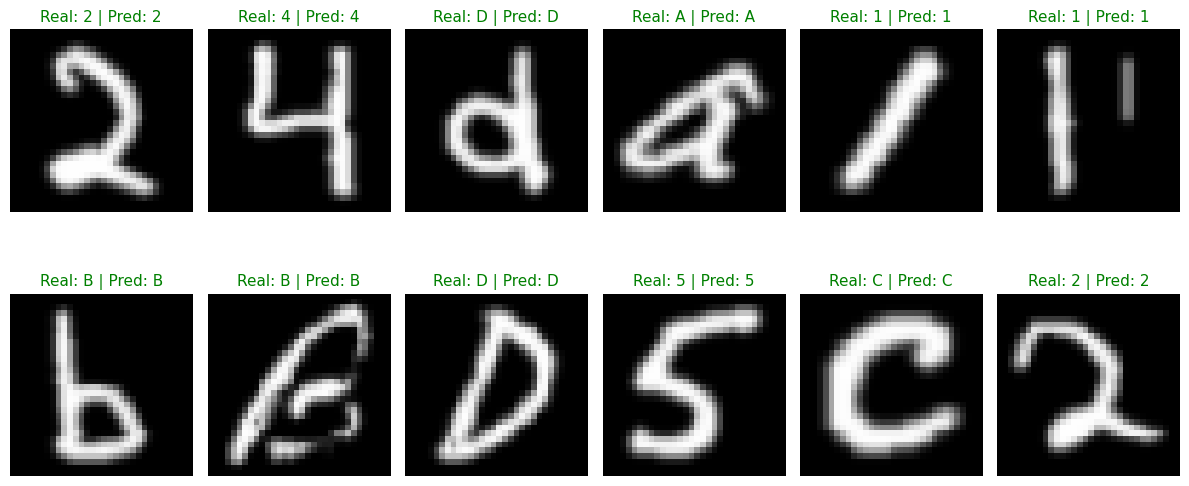

In [7]:
# Coleta um lote de teste para visualização
images_batch, labels_batch = next(iter(test_ds))
predictions = model.predict(images_batch)
pred_labels = np.argmax(predictions, axis=1)

# Plota 12 amostras com Real vs Predito
plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(2, 6, i + 1)
    plt.imshow(images_batch[i].numpy())
    true_char = CLASS_NAMES[labels_batch[i]]
    pred_char = CLASS_NAMES[pred_labels[i]]
    color = 'green' if true_char == pred_char else 'red'
    plt.title(f"Real: {true_char} | Pred: {pred_char}", color=color, fontsize=11)
    plt.axis('off')
plt.tight_layout()
plt.show()